In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.shape

(1338, 7)

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


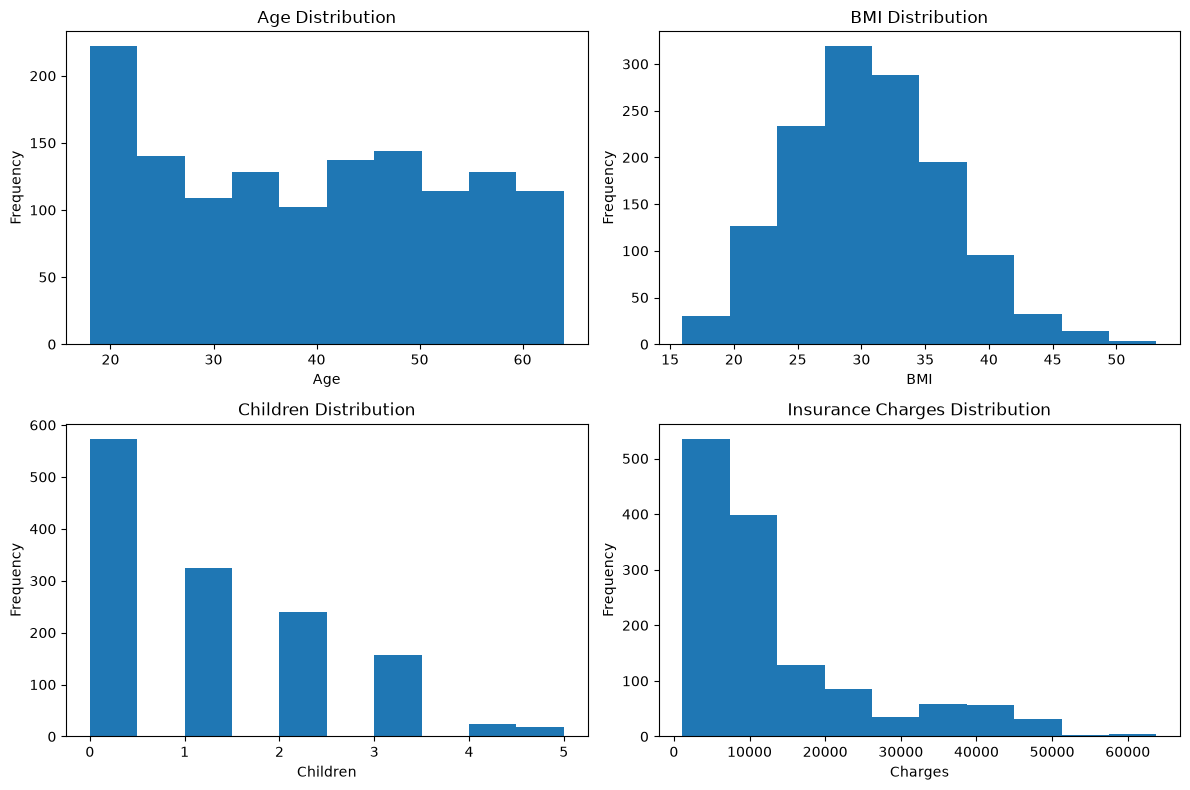

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["age"])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(df["bmi"])
axes[0, 1].set_title("BMI Distribution")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].hist(df["children"])
axes[1, 0].set_title("Children Distribution")
axes[1, 0].set_xlabel("Children")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(df["charges"])
axes[1, 1].set_title("Insurance Charges Distribution")
axes[1, 1].set_xlabel("Charges")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

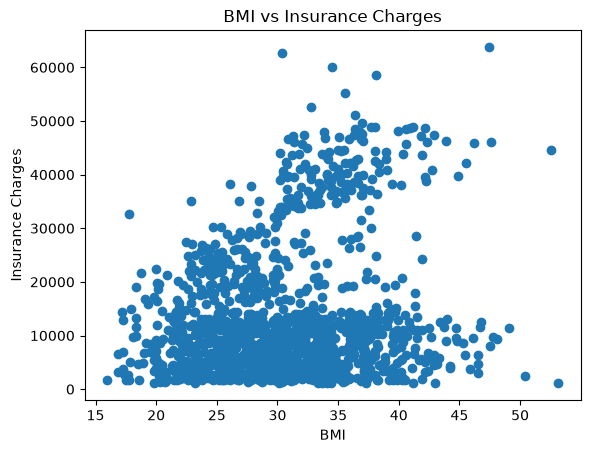

In [13]:
plt.scatter(df["bmi"], df["charges"])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

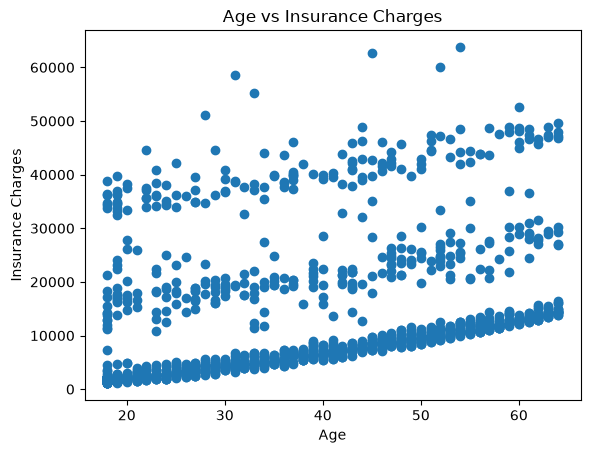

In [18]:
plt.scatter(df["age"], df["charges"])
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.show()

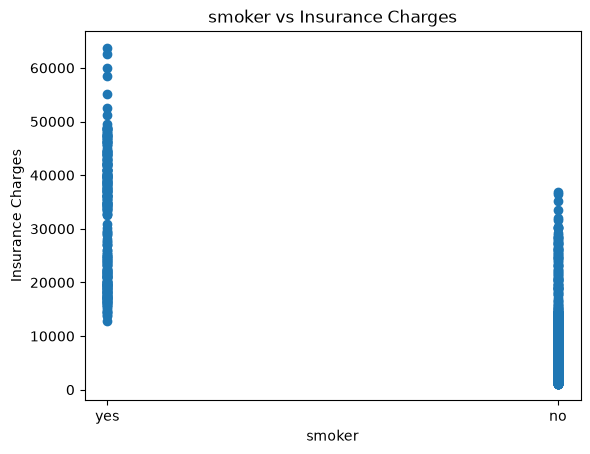

In [21]:
plt.scatter(df["smoker"], df["charges"])
plt.xlabel("smoker")
plt.ylabel("Insurance Charges")
plt.title("smoker vs Insurance Charges")
plt.show()

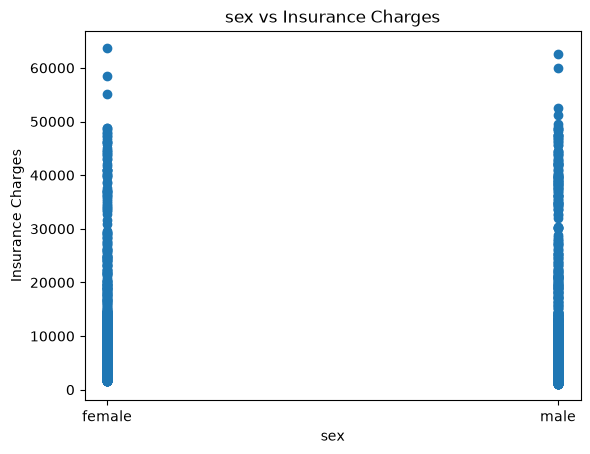

In [23]:
plt.scatter(df["sex"], df["charges"])
plt.xlabel("sex")
plt.ylabel("Insurance Charges")
plt.title("sex vs Insurance Charges")
plt.show()

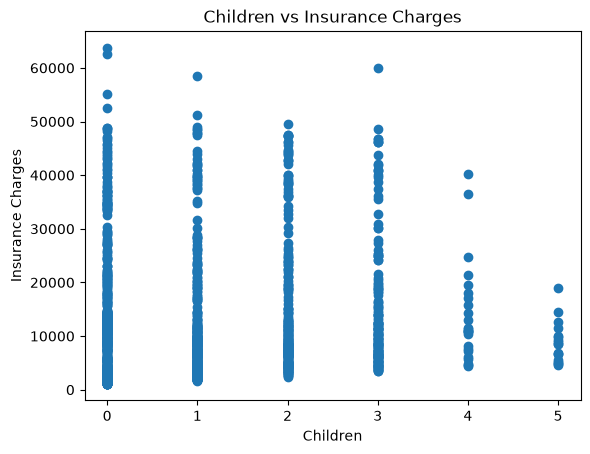

In [27]:
plt.scatter(df["children"], df["charges"])
plt.xlabel("Children")
plt.ylabel("Insurance Charges")
plt.title("Children vs Insurance Charges")
plt.show()

In [28]:
df["smoker_encoded"] = df["smoker"].map({"no": 0, "yes": 1})

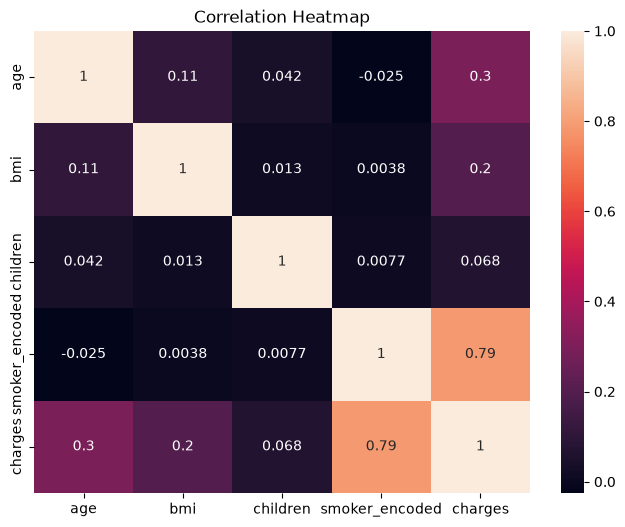

In [29]:
corr = df[["age", "bmi", "children", "smoker_encoded", "charges"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
X=df[["age","bmi","children","smoker_encoded"]]
y=df["charges"]

In [34]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 261.85, 333.41, 433.23,23626.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['age','bmi','children','smoker_encoded']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.247e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [43]:
y_pred = model.predict(X_test)

In [46]:
mse=mean_squared_error(y_test, y_pred)
rmse=mse ** 0.5
r2=r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 33948860.84184331
RMSE: 5826.56509805248
R²: 0.7684636242828374


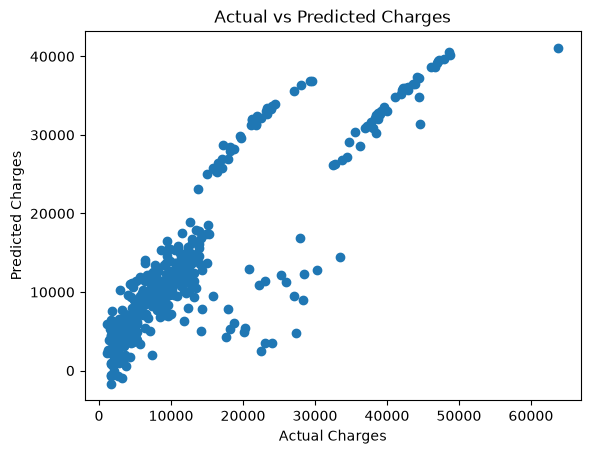

In [47]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [48]:
print(model.coef_)
print(model.intercept_)

[  261.84974458   333.40735476   433.22607604 23626.55992417]
-12470.177642441264


In [49]:
new_data = pd.DataFrame({
    "age": [25, 40, 50, 35, 60],
    "bmi": [22.5, 30.2, 28.5, 26.1, 32.0],
    "children": [1, 2, 3, 0, 2],
    "smoker_encoded": [0, 1, 0, 1, 0]
})

In [50]:
new_predictions = model.predict(new_data)
print(new_predictions)

[ 2010.95753032 32565.72633093 11424.09742551 29023.05530141
 14776.29453695]
